<a href="https://colab.research.google.com/github/OJB-Quantum/Generative-Layout-Notebooks/blob/main/CPW_Fibonacci_Word_Fractal_Resonator_with_GDSTK_PHIDL_NetworkX_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
!uv pip install phidl gdstk networkx matplotlib numpy

Using Python 3.13.15 environment at: /usr
Resolved 15 packages in 2.36s
Prepared 3 packages in 10.85s
Installed 3 packages in 2ms
 + gdspy==1.6.13
 + gdstk==1.0.1
 + phidl==1.7.2


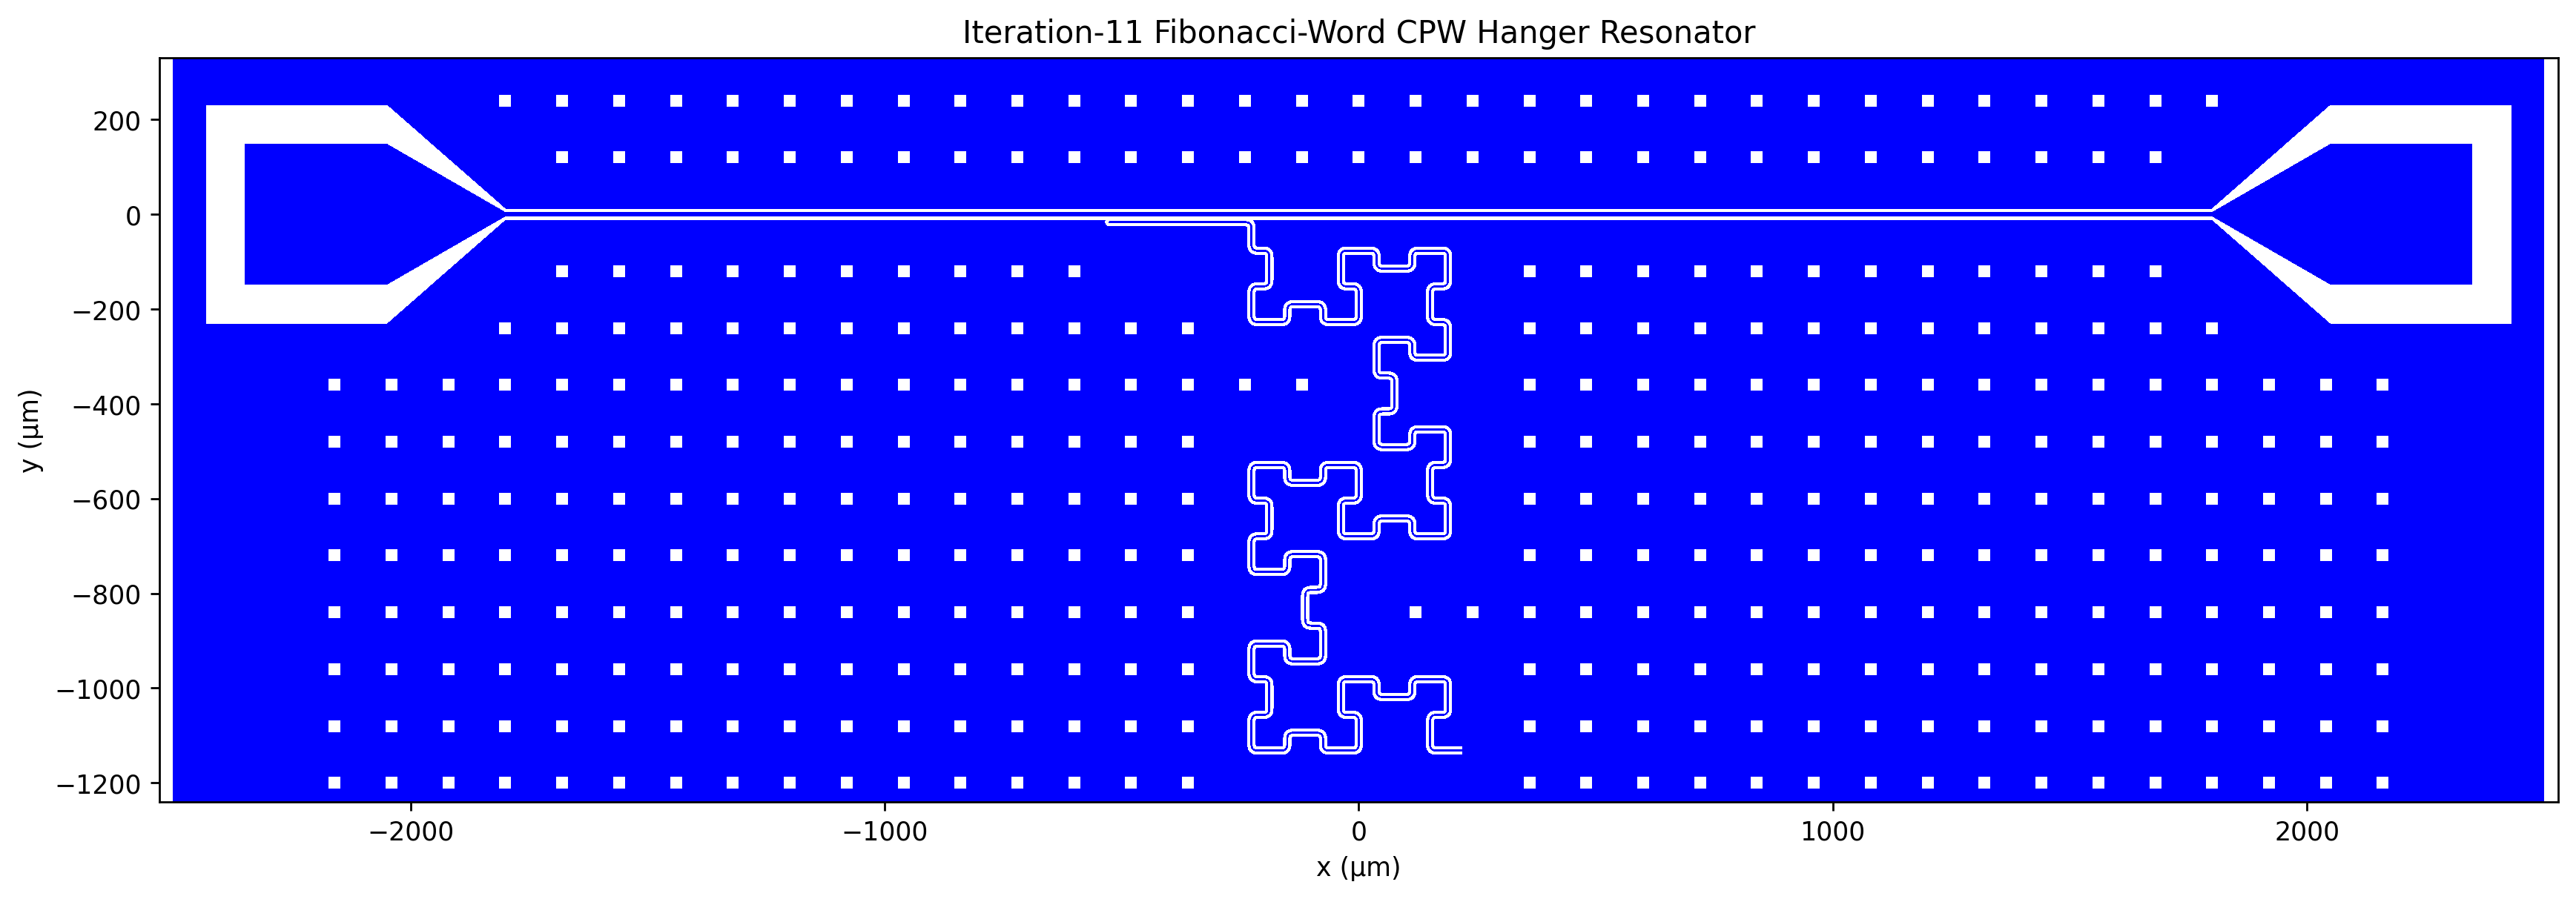

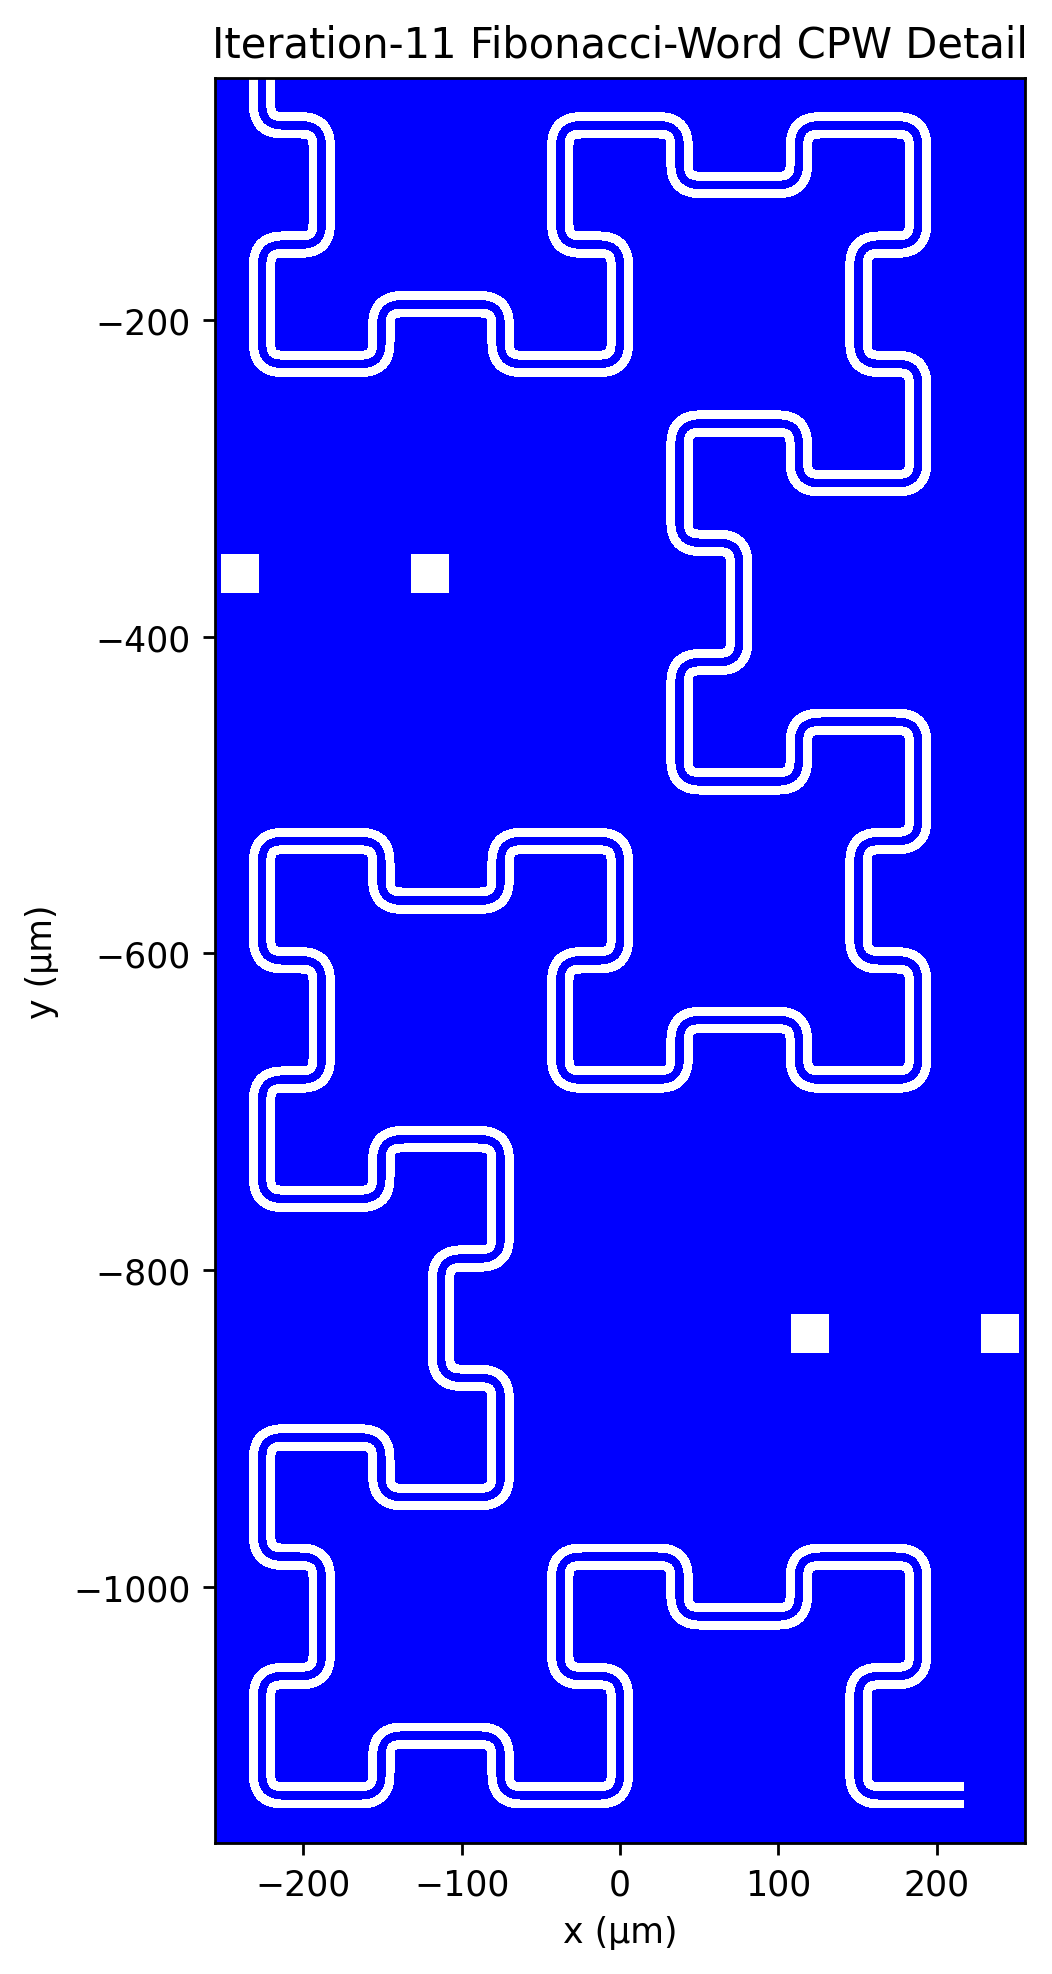


Package versions
  GDSTK:    1.0.1
  PHIDL:    1.7.2
  NetworkX: 3.6.1

Resonator
  Fibonacci iteration:       11
  Fibonacci word length:     144
  Solved segment length:     37.678 um
  Vertical route offset:     0.000 um
  Euler effective radius:    15.000 um
  CPW gap target:            5.000 um
  Measured CPW gap range:    5.0000 to 5.0000 um
  Target quarter-wave length:5353.437 um
  Routed centerline length:  5353.505 um
  Length error:              0.068492 um
  Estimated frequency:       6.999910 GHz
  Furthest tip distance:     1131.834 um
  Tip-distance mode:         automatic
  Coupler edge gap:          8.000 um
  Hanger coupler direction: reverse

Feedline and launchers
  Feedline trace width:      11.700 um
  Feedline CPW gap:          5.100 um
  Launcher pad:              300.0 x 300.0 um
  Launcher pad gap:          80.0 um
  Launcher pad-back gap:     80.0 um
  Launcher taper length:     250.0 um
  Launcher edge inset:       150.0 um

Cheesing and DRC
  Cheese holes:

In [21]:
"""Generate a frequency-targeted Fibonacci-word-fractal CPW hanger resonator.

The resonator is one CPW center conductor whose negative-tone slot pair follows
a finite Fibonacci word fractal below a parallel hanger coupler. NetworkX
defines routing topology, PHIDL supplies Euler-smoothed centerlines, and GDSTK
builds polygonal geometry, booleans, OASIS output, and CRC32 validation. The
feed uses continuous square-pad launcher polygons with matching tapered CPW
envelopes and equal side/back pad gaps.
"""

import importlib.metadata
import importlib.util
import inspect
import math
import os
from pathlib import Path
import pdb
import struct
import subprocess
import tempfile
import traceback
from dataclasses import dataclass, field
from typing import Callable, Dict, Final, List, Optional, Sequence, Tuple
import zlib

import gdstk
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
import networkx as nx
import numpy as np
from phidl import Device, Path as PhidlPath
import phidl.geometry as pg
import phidl.path as pp


# -----------------------------------------------------------------------------
# Control knobs - physical target
# -----------------------------------------------------------------------------

TARGET_FREQUENCY_GHZ = 7.0
EFFECTIVE_PERMITTIVITY = 4.0
PHASE_VELOCITY_FACTOR = 1.0

# Canonical Fibonacci word iteration. Iteration 9 contains 55 fractal segments.
FIBONACCI_ITERATION = 11

# None derives this distance from the Fibonacci iteration and electrical target.
FURTHEST_RESONATOR_TIP_UM: Optional[float] = None

# Conductor-edge separation in the parallel hanger coupler.
COUPLER_EDGE_GAP_UM = 8.0
COUPLER_LENGTH_UM = 300.0

# Default: reverse. Accepted values are "forward" and "reverse".
HANGER_COUPLER_DIRECTION = "reverse"


# -----------------------------------------------------------------------------
# Control knobs - feedline CPW and launchers
# -----------------------------------------------------------------------------

FEEDLINE_TRACE_WIDTH_UM: Final[float] = 11.7
FEEDLINE_GAP_UM: Final[float] = 5.1
LAUNCHER_PAD_LENGTH_UM: Final[float] = 300.0
LAUNCHER_PAD_WIDTH_UM: Final[float] = 300.0
LAUNCHER_PAD_GAP_UM: Final[float] = 80.0
LAUNCHER_TAPER_LENGTH_UM: Final[float] = 250.0
LAUNCHER_EDGE_INSET_UM: Final[float] = 150.0

# Match the side and back clearances around each square launcher pad.
LAUNCHER_BACK_GAP_UM: Final[float] = LAUNCHER_PAD_GAP_UM


# -----------------------------------------------------------------------------
# Control knobs - resonator CPW geometry
# -----------------------------------------------------------------------------

RESONATOR_TRACE_WIDTH_UM = 6.0
RESONATOR_GAP_UM = 5.0
RESONATOR_EULER_RADIUS_UM = 15.0
EULER_NUM_PTS_PER_360 = 256

# None derives the equal Fibonacci segment length from the frequency target.
FIBONACCI_SEGMENT_LENGTH_UM: Optional[float] = None
MIN_FRACTAL_GROUND_WEB_UM = 4.0
FRACTAL_TOP_CLEARANCE_RADII = 4.0

SHORT_BAR_GROUND_OVERLAP_UM = 1.0


# -----------------------------------------------------------------------------
# Control knobs - chip, fabrication grid, and layers
# -----------------------------------------------------------------------------

CHIP_WIDTH_UM = 5000.0
CHIP_HEIGHT_UM = 5000.0
GRID_UM = 0.001
BOOLEAN_PRECISION_UM = 0.001
PATH_TOLERANCE_UM = 0.001
GEOMETRY_COMPARISON_TOLERANCE_UM = GRID_UM

METAL_LAYER = 3
METAL_DATATYPE = 0
PHIDL_DIAGNOSTIC_LAYER = 99


# -----------------------------------------------------------------------------
# Control knobs - cheesing and avoidance
# -----------------------------------------------------------------------------

ENABLE_CHEESING = True
CHEESE_SIZE_UM = 25.0
CHEESE_PITCH_X_UM = 120.0
CHEESE_PITCH_Y_UM = 120.0
CHEESE_COMPONENT_KEEPOUT_UM = 80.0
CHEESE_EDGE_KEEPOUT_UM = 250.0


# -----------------------------------------------------------------------------
# Control knobs - DRC
# -----------------------------------------------------------------------------

MIN_TRACE_WIDTH_UM = 4.0
MIN_GAP_SPACING_UM = 2.0
MIN_TRACE_TO_TRACE_SPACING_UM = 4.0
TARGET_LENGTH_TOLERANCE_UM = 2.0
TIP_DISTANCE_TOLERANCE_UM = GRID_UM
RESONATOR_GAP_DRC_TOLERANCE_UM = 0.02

HALT_ON_DRC_WARNINGS = True
HALT_ON_DRC_VIOLATIONS = True


# -----------------------------------------------------------------------------
# Control knobs - hierarchy, output, diagnostics, and plotting
# -----------------------------------------------------------------------------

INCLUDE_JUNCTION_CELL = False
OUTPUT_OASIS = Path("fibonacci_word_fractal_hanger_7ghz.oas")
OASIS_COMPRESSION_LEVEL = 6
OASIS_STANDARD_PROPERTIES = False

RUN_RUNTIME_API_GUARDS = True
RUN_PYLINT_IF_FILE_BACKED = False
ENABLE_PDB_ON_ERROR = False

PLOT_DPI = 250
PLOT_COLOR = "#0000FF"
PLOT_BACKGROUND_COLOR = "#FFFFFF"
PLOT_MARGIN_UM = 100.0
PLOT_CROP_TO_COMPONENTS = True
PLOT_SHOW_CHEESE_HOLES = True
PLOT_SHOW_FRACTAL_DETAIL = True
PLOT_FRACTAL_DETAIL_MARGIN_UM = 30.0


# -----------------------------------------------------------------------------
# Constants
# -----------------------------------------------------------------------------

SPEED_OF_LIGHT_M_PER_S = 299_792_458.0


@dataclass(frozen=True)
class FeedlineGeometry:
    """Polygon sets describing the feedline and launcher CPW."""

    conductor: List[gdstk.Polygon]
    envelope: List[gdstk.Polygon]
    slots: List[gdstk.Polygon]


@dataclass(frozen=True)
class FibonacciRouteSolution:
    """Solved geometric parameters for the Fibonacci hanger route."""

    segment_um: float
    vertical_offset_um: float
    furthest_tip_um: float
    path_length_um: float


@dataclass(frozen=True)
class ResonatorGeometry:
    """Polygon sets and centerline metrics for the Fibonacci resonator."""

    centerline_points: np.ndarray
    waypoints: np.ndarray
    conductor: List[gdstk.Polygon]
    conductor_with_short: List[gdstk.Polygon]
    envelope: List[gdstk.Polygon]
    slots: List[gdstk.Polygon]
    short_bar: gdstk.Polygon
    fractal_iteration: int
    fractal_segment_um: float
    fractal_word_length: int
    vertical_offset_um: float
    path_length_um: float
    coupler_y_um: float
    tip_distance_um: float


@dataclass
class DrcReport:
    """Collect fatal warnings and design-rule violations."""

    warnings: List[str] = field(default_factory=list)
    violations: List[str] = field(default_factory=list)
    metrics: Dict[str, float] = field(default_factory=dict)

    def halt_if_required(self) -> None:
        """Raise immediately after the completed DRC pass if issues exist."""
        messages: List[str] = []
        if HALT_ON_DRC_WARNINGS and self.warnings:
            messages.extend(f"WARNING: {item}" for item in self.warnings)
        if HALT_ON_DRC_VIOLATIONS and self.violations:
            messages.extend(f"VIOLATION: {item}" for item in self.violations)
        if messages:
            raise RuntimeError("DRC failed:\n" + "\n".join(messages))


@dataclass(frozen=True)
class LayoutState:
    """Geometry bundle passed into DRC and export routines."""

    graph: nx.Graph
    chip: gdstk.Polygon
    feedline: FeedlineGeometry
    resonator: ResonatorGeometry
    cheese_holes: List[gdstk.Polygon]
    cheese_keepout: List[gdstk.Polygon]
    final_metal: List[gdstk.Polygon]
    library: gdstk.Library
    top_cell: gdstk.Cell


class PhidlHierarchyEngine:
    """Manage PHIDL hierarchy and cheesing computations without a CAD framework."""

    def __init__(self) -> None:
        self.root = Device("PHIDL_TOP")
        self.cells: Dict[str, Device] = {}
        self.diagnostic_cells: Dict[str, Device] = {}

    def add_polygon_cell(
        self,
        name: str,
        polygons: Sequence[gdstk.Polygon],
        layer: int,
        attach_to_root: bool = True,
    ) -> Device:
        """Mirror GDSTK polygons into a PHIDL Device hierarchy."""
        device = Device(name)
        for polygon in polygons:
            device.add_polygon(np.asarray(polygon.points), layer=layer)
        if attach_to_root:
            self.root.add_ref(device)
            self.cells[name] = device
        else:
            self.diagnostic_cells[name] = device
        return device

    def add_junction_cell_if_requested(
        self,
        junction_device: Optional[Device] = None,
    ) -> None:
        """Attach a junction cell only for designs that request one."""
        if INCLUDE_JUNCTION_CELL is False:
            return
        if junction_device is None:
            raise RuntimeError(
                "INCLUDE_JUNCTION_CELL=True requires an explicit PHIDL Device."
            )
        self.root.add_ref(junction_device)
        self.cells[junction_device.name] = junction_device

    def compute_cheesing(
        self,
        component_envelopes: Sequence[gdstk.Polygon],
    ) -> Tuple[List[gdstk.Polygon], List[gdstk.Polygon]]:
        """Generate complete cheese squares outside expanded component keepouts."""
        keepout = gdstk.offset(
            component_envelopes,
            CHEESE_COMPONENT_KEEPOUT_UM,
            join="miter",
            tolerance=2,
            precision=BOOLEAN_PRECISION_UM,
            use_union=True,
            layer=PHIDL_DIAGNOSTIC_LAYER,
            datatype=0,
        )

        if ENABLE_CHEESING is False:
            return [], keepout

        half_diagonal = CHEESE_SIZE_UM / math.sqrt(2.0)
        center_exclusion = gdstk.offset(
            keepout,
            half_diagonal,
            join="miter",
            tolerance=2,
            precision=BOOLEAN_PRECISION_UM,
            use_union=True,
            layer=PHIDL_DIAGNOSTIC_LAYER,
            datatype=0,
        )

        xmin = -CHIP_WIDTH_UM / 2.0 + CHEESE_EDGE_KEEPOUT_UM
        xmax = CHIP_WIDTH_UM / 2.0 - CHEESE_EDGE_KEEPOUT_UM
        ymin = -CHIP_HEIGHT_UM / 2.0 + CHEESE_EDGE_KEEPOUT_UM
        ymax = CHIP_HEIGHT_UM / 2.0 - CHEESE_EDGE_KEEPOUT_UM

        x_centers = aligned_grid_values(
            xmin + CHEESE_SIZE_UM / 2.0,
            xmax - CHEESE_SIZE_UM / 2.0,
            CHEESE_PITCH_X_UM,
        )
        y_centers = aligned_grid_values(
            ymin + CHEESE_SIZE_UM / 2.0,
            ymax - CHEESE_SIZE_UM / 2.0,
            CHEESE_PITCH_Y_UM,
        )

        centers = np.array(
            [(x_value, y_value) for y_value in y_centers for x_value in x_centers],
            dtype=float,
        )
        if centers.size == 0:
            return [], keepout

        excluded = np.asarray(gdstk.inside(centers, center_exclusion), dtype=bool)
        cheese_holes: List[gdstk.Polygon] = []
        half_size = CHEESE_SIZE_UM / 2.0
        for center, is_excluded in zip(centers, excluded):
            if bool(is_excluded):
                continue
            x_value, y_value = center
            cheese_holes.append(
                rectangle_polygon(
                    x_value - half_size,
                    y_value - half_size,
                    x_value + half_size,
                    y_value + half_size,
                    layer=METAL_LAYER,
                    datatype=METAL_DATATYPE,
                )
            )
        return cheese_holes, keepout


def package_version(package_name: str) -> str:
    """Return an installed package version without assuming __version__."""
    try:
        return importlib.metadata.version(package_name)
    except importlib.metadata.PackageNotFoundError:
        return "unknown"


def validate_api_surface() -> None:
    """Fail early on incompatible namespaces, classes, and signatures."""
    required_attributes = [
        (gdstk, "Library", "gdstk.Library"),
        (gdstk, "Cell", "gdstk.Cell"),
        (gdstk, "Polygon", "gdstk.Polygon"),
        (gdstk, "FlexPath", "gdstk.FlexPath"),
        (gdstk, "boolean", "gdstk.boolean"),
        (gdstk, "offset", "gdstk.offset"),
        (gdstk, "inside", "gdstk.inside"),
        (gdstk, "read_oas", "gdstk.read_oas"),
        (gdstk, "oas_validate", "gdstk.oas_validate"),
        (pp, "euler", "phidl.path.euler"),
        (pp, "smooth", "phidl.path.smooth"),
        (pg, "rectangle", "phidl.geometry.rectangle"),
        (Device, "add_polygon", "phidl.Device.add_polygon"),
        (Device, "add_ref", "phidl.Device.add_ref"),
    ]
    missing = [
        label
        for obj, name, label in required_attributes
        if hasattr(obj, name) is False
    ]
    if missing:
        raise RuntimeError("Missing required API symbols: " + ", ".join(missing))

    rectangle_signature = inspect.signature(pg.rectangle)
    if "size" not in rectangle_signature.parameters:
        raise RuntimeError("PHIDL rectangle API lacks the documented size parameter.")

    euler_signature = inspect.signature(pp.euler)
    for parameter in ("radius", "angle", "use_eff", "num_pts"):
        if parameter not in euler_signature.parameters:
            raise RuntimeError(
                f"PHIDL Euler API lacks the documented {parameter!r} parameter."
            )

    probe_path = PhidlPath([(0.0, 0.0), (1.0, 0.0)])
    if hasattr(probe_path, "points") is False:
        raise RuntimeError("PHIDL Path lacks the documented points array.")

    probe_library = gdstk.Library()
    if hasattr(probe_library, "write_oas") is False:
        raise RuntimeError("GDSTK Library lacks write_oas().")


def maybe_run_pylint() -> None:
    """Run pylint errors-only mode when this code exists as a file."""
    if RUN_PYLINT_IF_FILE_BACKED is False:
        return
    if importlib.util.find_spec("pylint") is None:
        raise RuntimeError("RUN_PYLINT_IF_FILE_BACKED=True requires pylint.")
    source_file = globals().get("__file__")
    if source_file is None:
        raise RuntimeError("Pylint mode requires a file-backed Python source.")
    result = subprocess.run(
        ["python", "-m", "pylint", "--errors-only", str(source_file)],
        check=False,
        capture_output=True,
        text=True,
    )
    if result.returncode != 0:
        raise RuntimeError("Pylint errors:\n" + result.stdout + result.stderr)


def snap_value(value: float) -> float:
    """Snap one coordinate to the fabrication grid."""
    return round(value / GRID_UM) * GRID_UM


def snap_points(points: np.ndarray) -> np.ndarray:
    """Snap an Nx2 point array and remove consecutive duplicate vertices."""
    snapped = np.round(np.asarray(points, dtype=float) / GRID_UM) * GRID_UM
    if len(snapped) <= 1:
        return snapped
    keep = np.concatenate(
        ([True], np.any(np.abs(np.diff(snapped, axis=0)) > GRID_UM * 1e-6, axis=1))
    )
    return snapped[keep]


def aligned_grid_values(minimum: float, maximum: float, pitch: float) -> np.ndarray:
    """Return globally aligned pitch values bounded by minimum and maximum."""
    first_index = math.ceil(minimum / pitch - 1e-12)
    last_index = math.floor(maximum / pitch + 1e-12)
    if first_index > last_index:
        return np.empty(0, dtype=float)
    indices = np.arange(first_index, last_index + 1, dtype=float)
    return snap_points_1d(indices * pitch)


def snap_points_1d(values: np.ndarray) -> np.ndarray:
    """Snap a one-dimensional coordinate array."""
    return np.round(np.asarray(values, dtype=float) / GRID_UM) * GRID_UM


def rectangle_polygon(
    xmin: float,
    ymin: float,
    xmax: float,
    ymax: float,
    layer: int,
    datatype: int,
) -> gdstk.Polygon:
    """Create an axis-aligned rectangle using the stable Polygon constructor."""
    points = snap_points(
        np.array(
            [
                [xmin, ymin],
                [xmax, ymin],
                [xmax, ymax],
                [xmin, ymax],
            ],
            dtype=float,
        )
    )
    return gdstk.Polygon(points, layer=layer, datatype=datatype)


def trapezoid_x_polygon(
    x0: float,
    x1: float,
    width0: float,
    width1: float,
    layer: int,
    datatype: int,
) -> gdstk.Polygon:
    """Create a taper whose width changes linearly along x."""
    points = snap_points(
        np.array(
            [
                [x0, -width0 / 2.0],
                [x1, -width1 / 2.0],
                [x1, width1 / 2.0],
                [x0, width0 / 2.0],
            ],
            dtype=float,
        )
    )
    return gdstk.Polygon(points, layer=layer, datatype=datatype)


def oriented_rectangle(
    center: Sequence[float],
    tangent: Sequence[float],
    along_tangent: float,
    across_tangent: float,
    layer: int,
    datatype: int,
) -> gdstk.Polygon:
    """Create a rectangle oriented to a local path tangent."""
    center_array = np.asarray(center, dtype=float)
    tangent_array = np.asarray(tangent, dtype=float)
    tangent_array /= np.linalg.norm(tangent_array)
    normal_array = np.array([-tangent_array[1], tangent_array[0]])
    half_along = along_tangent / 2.0
    half_across = across_tangent / 2.0
    corners = np.array(
        [
            center_array - half_along * tangent_array - half_across * normal_array,
            center_array + half_along * tangent_array - half_across * normal_array,
            center_array + half_along * tangent_array + half_across * normal_array,
            center_array - half_along * tangent_array + half_across * normal_array,
        ]
    )
    return gdstk.Polygon(snap_points(corners), layer=layer, datatype=datatype)


def union_polygons(
    polygons: Sequence[gdstk.Polygon],
    layer: int = METAL_LAYER,
    datatype: int = METAL_DATATYPE,
) -> List[gdstk.Polygon]:
    """Union a polygon sequence with the configured boolean precision."""
    if len(polygons) == 0:
        return []
    return gdstk.boolean(
        polygons,
        [],
        "or",
        precision=BOOLEAN_PRECISION_UM,
        layer=layer,
        datatype=datatype,
    )


def subtract_polygons(
    minuend: Sequence[gdstk.Polygon],
    subtrahend: Sequence[gdstk.Polygon],
    layer: int = METAL_LAYER,
    datatype: int = METAL_DATATYPE,
) -> List[gdstk.Polygon]:
    """Return minuend minus subtrahend."""
    if len(minuend) == 0:
        return []
    if len(subtrahend) == 0:
        return union_polygons(minuend, layer=layer, datatype=datatype)
    return gdstk.boolean(
        minuend,
        subtrahend,
        "not",
        precision=BOOLEAN_PRECISION_UM,
        layer=layer,
        datatype=datatype,
    )


def intersect_polygons(
    first: Sequence[gdstk.Polygon],
    second: Sequence[gdstk.Polygon],
) -> List[gdstk.Polygon]:
    """Return the polygonal intersection between two sets."""
    if len(first) == 0 or len(second) == 0:
        return []
    return gdstk.boolean(
        first,
        second,
        "and",
        precision=BOOLEAN_PRECISION_UM,
        layer=PHIDL_DIAGNOSTIC_LAYER,
        datatype=0,
    )


def point_inside_polygons(
    point: np.ndarray,
    polygons: Sequence[gdstk.Polygon],
) -> bool:
    """Return whether one point lies inside a polygon collection."""
    result = gdstk.inside(np.asarray([point], dtype=float), polygons)
    return bool(result[0])


def boundary_distance_from_centerline(
    center: np.ndarray,
    normal: np.ndarray,
    side: float,
    polygons: Sequence[gdstk.Polygon],
    expected_boundary_um: float,
    search_margin_um: float,
) -> float:
    """Locate a polygon boundary along a centerline normal by bisection."""
    direction = side * np.asarray(normal, dtype=float)
    low = 0.0
    high = expected_boundary_um + search_margin_um

    if not point_inside_polygons(center, polygons):
        raise RuntimeError("Gap DRC sample center lies outside its CPW polygon.")

    high_point = center + high * direction
    if point_inside_polygons(high_point, polygons):
        raise RuntimeError(
            "Gap DRC could not bracket a CPW boundary before the adjacent turn."
        )

    for _ in range(48):
        middle = 0.5 * (low + high)
        sample = center + middle * direction
        if point_inside_polygons(sample, polygons):
            low = middle
        else:
            high = middle
    return 0.5 * (low + high)


def sampled_resonator_gap_widths_um(
    resonator: ResonatorGeometry,
) -> np.ndarray:
    """Measure actual CPW slot widths on straight Fibonacci sections."""
    waypoints = np.asarray(resonator.waypoints[2:], dtype=float)
    if len(waypoints) < 2:
        return np.empty(0, dtype=float)

    trace_half_width = RESONATOR_TRACE_WIDTH_UM / 2.0
    expected_outer_boundary = trace_half_width + RESONATOR_GAP_UM
    available_ground_web = (
        resonator.fractal_segment_um
        - RESONATOR_TRACE_WIDTH_UM
        - 2.0 * RESONATOR_GAP_UM
    )
    search_margin = max(
        10.0 * GRID_UM,
        min(RESONATOR_GAP_UM / 2.0, max(available_ground_web / 4.0, GRID_UM)),
    )

    measured: List[float] = []
    for start, end in zip(waypoints[:-1], waypoints[1:]):
        delta = end - start
        segment_length = float(np.linalg.norm(delta))
        minimum_straight = 2.2 * RESONATOR_EULER_RADIUS_UM
        if (
            segment_length + GEOMETRY_COMPARISON_TOLERANCE_UM
            < minimum_straight
        ):
            continue

        tangent = delta / segment_length
        normal = np.array([-tangent[1], tangent[0]], dtype=float)
        center = 0.5 * (start + end)

        for side in (-1.0, 1.0):
            conductor_edge = boundary_distance_from_centerline(
                center,
                normal,
                side,
                resonator.conductor,
                trace_half_width,
                search_margin,
            )
            envelope_edge = boundary_distance_from_centerline(
                center,
                normal,
                side,
                resonator.envelope,
                expected_outer_boundary,
                search_margin,
            )
            measured.append(envelope_edge - conductor_edge)

    return np.asarray(measured, dtype=float)


def target_quarter_wave_length_um() -> float:
    """Return the first-order guided quarter-wave length in micrometers."""
    frequency_hz = TARGET_FREQUENCY_GHZ * 1e9
    phase_velocity = (
        SPEED_OF_LIGHT_M_PER_S
        * PHASE_VELOCITY_FACTOR
        / math.sqrt(EFFECTIVE_PERMITTIVITY)
    )
    return phase_velocity / (4.0 * frequency_hz) * 1e6


def frequency_from_length_ghz(length_um: float) -> float:
    """Invert the first-order guided quarter-wave relation."""
    phase_velocity = (
        SPEED_OF_LIGHT_M_PER_S
        * PHASE_VELOCITY_FACTOR
        / math.sqrt(EFFECTIVE_PERMITTIVITY)
    )
    return phase_velocity / (4.0 * length_um * 1e-6) / 1e9


def coupler_center_y_um() -> float:
    """Return resonator coupler y from the requested conductor-edge gap."""
    return snap_value(
        -(
            FEEDLINE_TRACE_WIDTH_UM / 2.0
            + COUPLER_EDGE_GAP_UM
            + RESONATOR_TRACE_WIDTH_UM / 2.0
        )
    )


def hanger_coupler_direction_sign() -> float:
    """Return the signed x direction of the parallel hanger coupler."""
    direction = HANGER_COUPLER_DIRECTION.strip().lower()
    if direction == "forward":
        return 1.0
    if direction == "reverse":
        return -1.0
    raise ValueError(
        'HANGER_COUPLER_DIRECTION must be "forward" or "reverse".'
    )


def fibonacci_word(iteration: int) -> str:
    """Return the finite Fibonacci word for the requested iteration.

    The convention is F1 = "0", F2 = "01", and Fn = F(n-1) + F(n-2).
    Under this convention, iteration 9 contains 55 symbols.
    """
    if iteration < 1:
        raise ValueError("FIBONACCI_ITERATION must be at least 1.")
    if iteration == 1:
        return "0"
    if iteration == 2:
        return "01"

    previous = "0"
    current = "01"
    for _ in range(3, iteration + 1):
        previous, current = current, current + previous
    return current


def fibonacci_unit_points(iteration: int) -> np.ndarray:
    """Build canonical unit-lattice points using the odd-even drawing rule.

    The turtle starts along +x. Each symbol draws one unit segment. A zero
    turns left after an even one-based symbol position and right after an odd
    position; a one leaves the heading unchanged.
    """
    word = fibonacci_word(iteration)
    directions = np.array(
        [
            [1.0, 0.0],
            [0.0, 1.0],
            [-1.0, 0.0],
            [0.0, -1.0],
        ],
        dtype=float,
    )

    direction_index = 0
    current = np.array([0.0, 0.0], dtype=float)
    points = [current.copy()]

    for position, symbol in enumerate(word, start=1):
        current = current + directions[direction_index]
        points.append(current.copy())

        if symbol == "0":
            if position % 2 == 0:
                direction_index = (direction_index + 1) % 4
            else:
                direction_index = (direction_index - 1) % 4

    return np.asarray(points, dtype=float)


def fibonacci_unit_extents(iteration: int) -> Tuple[float, float, float, float]:
    """Return xmin, ymin, xmax, ymax for the unit Fibonacci curve."""
    points = fibonacci_unit_points(iteration)
    xmin, ymin = points.min(axis=0)
    xmax, ymax = points.max(axis=0)
    return float(xmin), float(ymin), float(xmax), float(ymax)


def fibonacci_top_clearance_um() -> float:
    """Return the centerline clearance from coupler level to fractal top."""
    return snap_value(
        FRACTAL_TOP_CLEARANCE_RADII * RESONATOR_EULER_RADIUS_UM
    )


def build_fibonacci_waypoints(
    segment_um: float,
    vertical_offset_um: float = 0.0,
) -> np.ndarray:
    """Build the hanger coupler, stem, and Fibonacci-fractal waypoints."""
    if segment_um <= 0.0:
        raise ValueError("Fibonacci segment length must be positive.")
    if vertical_offset_um < 0.0:
        raise ValueError("Fibonacci vertical offset cannot be negative.")

    unit_points = fibonacci_unit_points(FIBONACCI_ITERATION)
    xmin, ymin, xmax, ymax = fibonacci_unit_extents(FIBONACCI_ITERATION)

    scaled_width = (xmax - xmin) * segment_um
    anchor_x = -0.5 * scaled_width - xmin * segment_um

    if FURTHEST_RESONATOR_TIP_UM is None:
        fractal_top_y = (
            coupler_center_y_um()
            - fibonacci_top_clearance_um()
            - vertical_offset_um
        )
        anchor_y = fractal_top_y - ymax * segment_um
    else:
        if vertical_offset_um > GRID_UM / 2.0:
            raise ValueError(
                "A manual FURTHEST_RESONATOR_TIP_UM value cannot be combined "
                "with an automatic vertical offset."
            )
        anchor_y = -FURTHEST_RESONATOR_TIP_UM - ymin * segment_um

    fractal_points = np.column_stack(
        (
            anchor_x + unit_points[:, 0] * segment_um,
            anchor_y + unit_points[:, 1] * segment_um,
        )
    )

    coupler_y = coupler_center_y_um()
    coupler_open_x = (
        anchor_x
        + hanger_coupler_direction_sign() * COUPLER_LENGTH_UM
    )
    points = np.vstack(
        (
            np.array(
                [
                    [coupler_open_x, coupler_y],
                    [anchor_x, coupler_y],
                ],
                dtype=float,
            ),
            fractal_points,
        )
    )
    return snap_points(points)


def smooth_waypoints_with_phidl(waypoints: np.ndarray) -> np.ndarray:
    """Apply effective-radius Euler smoothing with the PHIDL path module."""
    smooth_path = pp.smooth(
        points=waypoints,
        radius=RESONATOR_EULER_RADIUS_UM,
        corner_fun=pp.euler,
        p=1.0,
        use_eff=True,
        num_pts=EULER_NUM_PTS_PER_360,
    )
    return snap_points(np.asarray(smooth_path.points, dtype=float))


def centerline_length_um(points: np.ndarray) -> float:
    """Compute polyline arc length from an Nx2 array."""
    if len(points) < 2:
        return 0.0
    return float(np.linalg.norm(np.diff(points, axis=0), axis=1).sum())


def minimum_waypoint_segment_um(points: np.ndarray) -> float:
    """Return the shortest nonzero waypoint segment."""
    differences = np.linalg.norm(np.diff(points, axis=0), axis=1)
    positive = differences[differences > GRID_UM / 2.0]
    if positive.size == 0:
        return 0.0
    return float(positive.min())


def minimum_fibonacci_segment_um() -> float:
    """Return the minimum segment compatible with CPW and Euler constraints."""
    minimum_segment = max(
        2.2 * RESONATOR_EULER_RADIUS_UM,
        RESONATOR_TRACE_WIDTH_UM
        + 2.0 * RESONATOR_GAP_UM
        + MIN_FRACTAL_GROUND_WEB_UM,
    )
    minimum_segment += GEOMETRY_COMPARISON_TOLERANCE_UM
    return math.ceil(minimum_segment / GRID_UM) * GRID_UM


def resonator_chip_margin_um() -> float:
    """Return the minimum centerline margin from the chip boundary."""
    return snap_value(
        RESONATOR_TRACE_WIDTH_UM / 2.0 + RESONATOR_GAP_UM + GRID_UM
    )


def maximum_fibonacci_segment_um() -> float:
    """Return the largest segment compatible with placement and chip bounds."""
    xmin, ymin, xmax, ymax = fibonacci_unit_extents(FIBONACCI_ITERATION)
    horizontal_span = xmax - xmin
    vertical_span = ymax - ymin
    margin = resonator_chip_margin_um()

    limits: List[float] = []
    if horizontal_span > 0.0:
        horizontal_available = CHIP_WIDTH_UM - 2.0 * margin
        if horizontal_available <= 0.0:
            raise RuntimeError("Chip width leaves no room for the resonator.")
        limits.append(horizontal_available / horizontal_span)

    if FURTHEST_RESONATOR_TIP_UM is None:
        fractal_top_y = coupler_center_y_um() - fibonacci_top_clearance_um()
        lower_centerline_limit = -CHIP_HEIGHT_UM / 2.0 + margin
        vertical_available = fractal_top_y - lower_centerline_limit
        if vertical_span > 0.0:
            if vertical_available <= 0.0:
                raise RuntimeError("Chip height leaves no room below the coupler.")
            limits.append(vertical_available / vertical_span)
    else:
        if FURTHEST_RESONATOR_TIP_UM <= 0.0:
            raise ValueError("FURTHEST_RESONATOR_TIP_UM must be positive.")
        upper_centerline_limit = (
            coupler_center_y_um() - fibonacci_top_clearance_um()
        )
        if vertical_span > 0.0:
            top_available = FURTHEST_RESONATOR_TIP_UM + upper_centerline_limit
            if top_available <= 0.0:
                raise RuntimeError(
                    "The requested resonator depth leaves no room below the coupler."
                )
            limits.append(top_available / vertical_span)

    if not limits:
        raise RuntimeError(
            "Fibonacci geometry has no finite segment-size constraint."
        )
    return math.floor(min(limits) / GRID_UM) * GRID_UM


def maximum_auto_vertical_offset_um(segment_um: float) -> float:
    """Return the downward offset available after choosing a segment length."""
    if FURTHEST_RESONATOR_TIP_UM is not None:
        return 0.0

    _, ymin, _, ymax = fibonacci_unit_extents(FIBONACCI_ITERATION)
    vertical_span = ymax - ymin
    fractal_top_y = coupler_center_y_um() - fibonacci_top_clearance_um()
    lower_centerline_limit = (
        -CHIP_HEIGHT_UM / 2.0 + resonator_chip_margin_um()
    )
    fractal_bottom_y = fractal_top_y - vertical_span * segment_um
    available = fractal_bottom_y - lower_centerline_limit
    return max(0.0, math.floor(available / GRID_UM) * GRID_UM)


def fibonacci_route_metrics(
    segment_um: float,
    vertical_offset_um: float,
) -> Tuple[float, float]:
    """Return smoothed route length and furthest centerline distance."""
    waypoints = build_fibonacci_waypoints(segment_um, vertical_offset_um)
    minimum_straight = 2.2 * RESONATOR_EULER_RADIUS_UM
    shortest_segment = minimum_waypoint_segment_um(waypoints)
    if (
        shortest_segment + GEOMETRY_COMPARISON_TOLERANCE_UM
        < minimum_straight
    ):
        raise RuntimeError(
            "A Fibonacci route segment is too short for Euler smoothing."
        )
    smooth_points = smooth_waypoints_with_phidl(waypoints)
    path_length = centerline_length_um(smooth_points)
    furthest_tip = float(np.max(np.abs(smooth_points[:, 1])))
    return path_length, furthest_tip


def solve_monotonic_parameter(
    low: float,
    high: float,
    target: float,
    evaluate: Callable[[float], float],
) -> float:
    """Solve one monotonic geometric parameter on the fabrication grid."""
    original_low = low
    original_high = high
    for _ in range(64):
        middle = 0.5 * (low + high)
        if evaluate(middle) < target:
            low = middle
        else:
            high = middle

    solved = snap_value(0.5 * (low + high))
    candidates = [
        snap_value(solved + offset * GRID_UM) for offset in range(-4, 5)
    ]
    feasible = [
        value
        for value in candidates
        if original_low <= value <= original_high
    ]
    if not feasible:
        feasible = [solved]
    return min(feasible, key=lambda value: abs(evaluate(value) - target))


def solve_fibonacci_geometry() -> FibonacciRouteSolution:
    """Solve segment scale and depth for the requested resonator frequency."""
    target_length = target_quarter_wave_length_um()
    minimum_segment = minimum_fibonacci_segment_um()
    maximum_segment = maximum_fibonacci_segment_um()

    if maximum_segment + GRID_UM / 2.0 < minimum_segment:
        raise RuntimeError(
            "The selected Fibonacci iteration cannot satisfy the CPW, Euler, "
            "and chip-containment constraints."
        )

    if FIBONACCI_SEGMENT_LENGTH_UM is not None:
        segment_um = snap_value(FIBONACCI_SEGMENT_LENGTH_UM)
        if segment_um < minimum_segment:
            raise ValueError(
                "FIBONACCI_SEGMENT_LENGTH_UM is below the geometric minimum."
            )
        if segment_um > maximum_segment + GRID_UM / 2.0:
            raise ValueError(
                "FIBONACCI_SEGMENT_LENGTH_UM exceeds the chip-placement limit."
            )
    else:
        segment_um = minimum_segment

    if FURTHEST_RESONATOR_TIP_UM is not None:
        if FIBONACCI_SEGMENT_LENGTH_UM is None:
            low_length, _ = fibonacci_route_metrics(minimum_segment, 0.0)
            high_length, _ = fibonacci_route_metrics(maximum_segment, 0.0)
            if target_length < low_length - TARGET_LENGTH_TOLERANCE_UM:
                raise RuntimeError(
                    "The selected Fibonacci iteration is too long at the minimum "
                    "fabricable segment scale."
                )
            if target_length > high_length + TARGET_LENGTH_TOLERANCE_UM:
                raise RuntimeError(
                    "The requested resonator depth cannot reach the target "
                    "electrical length inside the chip."
                )
            segment_um = solve_monotonic_parameter(
                minimum_segment,
                maximum_segment,
                target_length,
                lambda value: fibonacci_route_metrics(value, 0.0)[0],
            )

        path_length, furthest_tip = fibonacci_route_metrics(segment_um, 0.0)
        return FibonacciRouteSolution(
            segment_um=segment_um,
            vertical_offset_um=0.0,
            furthest_tip_um=furthest_tip,
            path_length_um=path_length,
        )

    if FIBONACCI_SEGMENT_LENGTH_UM is None:
        low_length, _ = fibonacci_route_metrics(minimum_segment, 0.0)
        high_length, _ = fibonacci_route_metrics(maximum_segment, 0.0)
        if target_length < low_length - TARGET_LENGTH_TOLERANCE_UM:
            raise RuntimeError(
                "The selected Fibonacci iteration is too long at the minimum "
                "fabricable segment scale."
            )
        if target_length <= high_length + TARGET_LENGTH_TOLERANCE_UM:
            segment_um = solve_monotonic_parameter(
                minimum_segment,
                maximum_segment,
                target_length,
                lambda value: fibonacci_route_metrics(value, 0.0)[0],
            )
        else:
            segment_um = maximum_segment

    base_length, base_tip = fibonacci_route_metrics(segment_um, 0.0)
    if target_length <= base_length + TARGET_LENGTH_TOLERANCE_UM:
        return FibonacciRouteSolution(
            segment_um=segment_um,
            vertical_offset_um=0.0,
            furthest_tip_um=base_tip,
            path_length_um=base_length,
        )

    maximum_offset = maximum_auto_vertical_offset_um(segment_um)
    if maximum_offset <= 0.0:
        raise RuntimeError(
            "The selected Fibonacci iteration cannot reach the target electrical "
            "length inside the available chip height."
        )

    maximum_length, _ = fibonacci_route_metrics(segment_um, maximum_offset)
    if target_length > maximum_length + TARGET_LENGTH_TOLERANCE_UM:
        raise RuntimeError(
            "The selected Fibonacci iteration cannot reach the target electrical "
            "length after using the available resonator depth."
        )

    vertical_offset = solve_monotonic_parameter(
        0.0,
        maximum_offset,
        target_length,
        lambda value: fibonacci_route_metrics(segment_um, value)[0],
    )
    path_length, furthest_tip = fibonacci_route_metrics(
        segment_um,
        vertical_offset,
    )
    return FibonacciRouteSolution(
        segment_um=segment_um,
        vertical_offset_um=vertical_offset,
        furthest_tip_um=furthest_tip,
        path_length_um=path_length,
    )


def feedline_x_geometry() -> Dict[str, float]:
    """Calculate launcher and feedline x locations from chip-level knobs."""
    chip_left = -CHIP_WIDTH_UM / 2.0
    chip_right = CHIP_WIDTH_UM / 2.0

    left_pad_xmin = chip_left + LAUNCHER_EDGE_INSET_UM
    left_pad_xmax = left_pad_xmin + LAUNCHER_PAD_LENGTH_UM
    left_neck_x = left_pad_xmax + LAUNCHER_TAPER_LENGTH_UM

    right_pad_xmax = chip_right - LAUNCHER_EDGE_INSET_UM
    right_pad_xmin = right_pad_xmax - LAUNCHER_PAD_LENGTH_UM
    right_neck_x = right_pad_xmin - LAUNCHER_TAPER_LENGTH_UM

    if left_neck_x >= right_neck_x:
        raise RuntimeError("Launcher geometry consumes the available chip width.")

    return {
        "left_pad_xmin": snap_value(left_pad_xmin),
        "left_pad_xmax": snap_value(left_pad_xmax),
        "left_neck_x": snap_value(left_neck_x),
        "right_neck_x": snap_value(right_neck_x),
        "right_pad_xmin": snap_value(right_pad_xmin),
        "right_pad_xmax": snap_value(right_pad_xmax),
    }


def build_routing_graph(solution: FibonacciRouteSolution) -> nx.Graph:
    """Create the feedline and Fibonacci resonator topology with NetworkX."""
    graph = nx.Graph(name="FIBONACCI_WORD_CPW_ROUTING")
    x_geo = feedline_x_geometry()

    graph.add_node(
        "F_LEFT_PAD",
        net="feedline",
        kind="launcher_pad",
        center=((x_geo["left_pad_xmin"] + x_geo["left_pad_xmax"]) / 2.0, 0.0),
        bounds=(
            x_geo["left_pad_xmin"],
            -LAUNCHER_PAD_WIDTH_UM / 2.0,
            x_geo["left_pad_xmax"],
            LAUNCHER_PAD_WIDTH_UM / 2.0,
        ),
    )
    graph.add_node(
        "F_LEFT_NECK",
        net="feedline",
        kind="neck",
        center=(x_geo["left_neck_x"], 0.0),
    )
    graph.add_node(
        "F_RIGHT_NECK",
        net="feedline",
        kind="neck",
        center=(x_geo["right_neck_x"], 0.0),
    )
    graph.add_node(
        "F_RIGHT_PAD",
        net="feedline",
        kind="launcher_pad",
        center=((x_geo["right_pad_xmin"] + x_geo["right_pad_xmax"]) / 2.0, 0.0),
        bounds=(
            x_geo["right_pad_xmin"],
            -LAUNCHER_PAD_WIDTH_UM / 2.0,
            x_geo["right_pad_xmax"],
            LAUNCHER_PAD_WIDTH_UM / 2.0,
        ),
    )

    graph.add_edge(
        "F_LEFT_PAD",
        "F_LEFT_NECK",
        net="feedline",
        kind="taper",
        x0=x_geo["left_pad_xmax"],
        x1=x_geo["left_neck_x"],
        width0=LAUNCHER_PAD_WIDTH_UM,
        width1=FEEDLINE_TRACE_WIDTH_UM,
        gap0=LAUNCHER_PAD_GAP_UM,
        gap1=FEEDLINE_GAP_UM,
    )
    graph.add_edge(
        "F_LEFT_NECK",
        "F_RIGHT_NECK",
        net="feedline",
        kind="straight",
        x0=x_geo["left_neck_x"],
        x1=x_geo["right_neck_x"],
        width0=FEEDLINE_TRACE_WIDTH_UM,
        width1=FEEDLINE_TRACE_WIDTH_UM,
        gap0=FEEDLINE_GAP_UM,
        gap1=FEEDLINE_GAP_UM,
    )
    graph.add_edge(
        "F_RIGHT_NECK",
        "F_RIGHT_PAD",
        net="feedline",
        kind="taper",
        x0=x_geo["right_neck_x"],
        x1=x_geo["right_pad_xmin"],
        width0=FEEDLINE_TRACE_WIDTH_UM,
        width1=LAUNCHER_PAD_WIDTH_UM,
        gap0=FEEDLINE_GAP_UM,
        gap1=LAUNCHER_PAD_GAP_UM,
    )

    waypoints = build_fibonacci_waypoints(
        solution.segment_um,
        solution.vertical_offset_um,
    )
    previous_name: Optional[str] = None
    for order, point in enumerate(waypoints):
        node_name = f"R_{order:03d}"
        kind = "open_end" if order == 0 else "waypoint"
        if order == len(waypoints) - 1:
            kind = "short_end"
        graph.add_node(
            node_name,
            net="resonator",
            kind=kind,
            order=order,
            center=(float(point[0]), float(point[1])),
        )
        if previous_name is not None:
            graph.add_edge(
                previous_name,
                node_name,
                net="resonator",
                kind="route",
                width0=RESONATOR_TRACE_WIDTH_UM,
                width1=RESONATOR_TRACE_WIDTH_UM,
                gap0=RESONATOR_GAP_UM,
                gap1=RESONATOR_GAP_UM,
            )
        previous_name = node_name

    graph.graph["fractal_iteration"] = FIBONACCI_ITERATION
    graph.graph["hanger_coupler_direction"] = (
        HANGER_COUPLER_DIRECTION.strip().lower()
    )
    graph.graph["fractal_segment_um"] = solution.segment_um
    graph.graph["fractal_vertical_offset_um"] = solution.vertical_offset_um
    graph.graph["resolved_furthest_tip_um"] = solution.furthest_tip_um
    graph.graph["fractal_word_length"] = len(fibonacci_word(FIBONACCI_ITERATION))
    return graph


def resonator_waypoints_from_graph(graph: nx.Graph) -> np.ndarray:
    """Read the ordered resonator waypoint list from NetworkX node attributes."""
    nodes = [
        (int(data["order"]), data["center"])
        for _, data in graph.nodes(data=True)
        if data.get("net") == "resonator"
    ]
    nodes.sort(key=lambda item: item[0])
    return snap_points(np.asarray([point for _, point in nodes], dtype=float))


def build_launcher_polygons(
    feed_x_um: float,
    direction: int,
) -> Tuple[gdstk.Polygon, gdstk.Polygon]:
    """Create one square launcher and its continuous CPW envelope.

    The conductor is a single polygon containing the narrow feed connection,
    linear taper, and square pad.  The outer envelope follows the same taper,
    adds ``LAUNCHER_PAD_GAP_UM`` above and below the pad, and extends behind the
    pad by ``LAUNCHER_BACK_GAP_UM``.  Subtracting the conductor from this
    envelope produces the continuous U-shaped pad clearance and tapered CPW
    slots used by the reference launcher design.

    Args:
        feed_x_um: Feedline connection x coordinate at the narrow taper end.
        direction: ``-1`` for the left launcher or ``+1`` for the right.

    Returns:
        The launcher conductor polygon and matching outer-envelope polygon.
    """
    if direction not in (-1, 1):
        raise ValueError("direction must be -1 or +1")

    narrow_half = FEEDLINE_TRACE_WIDTH_UM / 2.0
    pad_half = LAUNCHER_PAD_WIDTH_UM / 2.0
    narrow_outer_half = narrow_half + FEEDLINE_GAP_UM
    pad_outer_half = pad_half + LAUNCHER_PAD_GAP_UM

    taper_pad_edge_x = feed_x_um + direction * LAUNCHER_TAPER_LENGTH_UM
    pad_back_x = taper_pad_edge_x + direction * LAUNCHER_PAD_LENGTH_UM
    envelope_back_x = pad_back_x + direction * LAUNCHER_BACK_GAP_UM

    conductor_points = np.array(
        [
            (feed_x_um, +narrow_half),
            (taper_pad_edge_x, +pad_half),
            (pad_back_x, +pad_half),
            (pad_back_x, -pad_half),
            (taper_pad_edge_x, -pad_half),
            (feed_x_um, -narrow_half),
        ],
        dtype=float,
    )
    envelope_points = np.array(
        [
            (feed_x_um, +narrow_outer_half),
            (taper_pad_edge_x, +pad_outer_half),
            (envelope_back_x, +pad_outer_half),
            (envelope_back_x, -pad_outer_half),
            (taper_pad_edge_x, -pad_outer_half),
            (feed_x_um, -narrow_outer_half),
        ],
        dtype=float,
    )

    conductor = gdstk.Polygon(
        snap_points(conductor_points),
        layer=METAL_LAYER,
        datatype=METAL_DATATYPE,
    )
    envelope = gdstk.Polygon(
        snap_points(envelope_points),
        layer=METAL_LAYER,
        datatype=METAL_DATATYPE,
    )
    return conductor, envelope


def build_feedline_geometry_from_graph(graph: nx.Graph) -> FeedlineGeometry:
    """Translate the feed graph into the reference-style CPW launchers.

    Each launcher is generated as one continuous conductor polygon and one
    continuous envelope polygon.  This keeps the square pad, taper, feedline
    neck, side gaps, and pad-back gap geometrically coherent instead of
    constructing the pad and taper from independent rectangles and trapezoids.
    """
    left_feed_x = float(graph.nodes["F_LEFT_NECK"]["center"][0])
    right_feed_x = float(graph.nodes["F_RIGHT_NECK"]["center"][0])

    left_conductor, left_envelope = build_launcher_polygons(
        left_feed_x,
        direction=-1,
    )
    right_conductor, right_envelope = build_launcher_polygons(
        right_feed_x,
        direction=+1,
    )

    feed_conductor = rectangle_polygon(
        left_feed_x,
        -FEEDLINE_TRACE_WIDTH_UM / 2.0,
        right_feed_x,
        FEEDLINE_TRACE_WIDTH_UM / 2.0,
        layer=METAL_LAYER,
        datatype=METAL_DATATYPE,
    )
    feed_outer_half = FEEDLINE_TRACE_WIDTH_UM / 2.0 + FEEDLINE_GAP_UM
    feed_envelope = rectangle_polygon(
        left_feed_x,
        -feed_outer_half,
        right_feed_x,
        feed_outer_half,
        layer=METAL_LAYER,
        datatype=METAL_DATATYPE,
    )

    conductor = union_polygons(
        [left_conductor, feed_conductor, right_conductor]
    )
    envelope = union_polygons(
        [left_envelope, feed_envelope, right_envelope]
    )
    slots = subtract_polygons(envelope, conductor)
    return FeedlineGeometry(
        conductor=conductor,
        envelope=envelope,
        slots=slots,
    )


def build_resonator_geometry_from_graph(graph: nx.Graph) -> ResonatorGeometry:
    """Translate the resonator graph into a constant-gap Euler-smoothed CPW.

    The resonator conductor is generated first.  Its CPW envelope is then formed
    by a geometric offset of exactly ``RESONATOR_GAP_UM`` from the finished
    conductor polygon. Subtracting the conductor from that envelope produces
    the two Fibonacci-route slots from one shared boundary construction. This avoids
    the width drift that can appear when the two slots are generated as
    independent offset FlexPath elements around a densely sampled Euler curve.
    """
    waypoints = resonator_waypoints_from_graph(graph)
    smooth_points = smooth_waypoints_with_phidl(waypoints)

    conductor_path = gdstk.FlexPath(
        smooth_points,
        RESONATOR_TRACE_WIDTH_UM,
        joins="natural",
        ends="round",
        tolerance=PATH_TOLERANCE_UM,
        simple_path=False,
        layer=METAL_LAYER,
        datatype=METAL_DATATYPE,
    )
    conductor = union_polygons(conductor_path.to_polygons())

    # Constant-gap construction: the outer CPW boundary is a geometric buffer
    # around the finished conductor. RESONATOR_GAP_UM sets the normal slot
    # width on straight sections and around every Euler bend.
    envelope = gdstk.offset(
        conductor,
        RESONATOR_GAP_UM,
        join="round",
        tolerance=64,
        precision=BOOLEAN_PRECISION_UM,
        use_union=True,
        layer=METAL_LAYER,
        datatype=METAL_DATATYPE,
    )
    if len(envelope) == 0:
        raise RuntimeError("Resonator CPW offset produced an empty envelope.")

    raw_slots = subtract_polygons(envelope, conductor)
    if len(raw_slots) == 0:
        raise RuntimeError("Resonator CPW gap construction produced zero slots.")

    tangent = smooth_points[-1] - smooth_points[-2]
    short_span = (
        RESONATOR_TRACE_WIDTH_UM
        + 2.0 * RESONATOR_GAP_UM
        + 2.0 * SHORT_BAR_GROUND_OVERLAP_UM
    )
    short_bar = oriented_rectangle(
        smooth_points[-1],
        tangent,
        along_tangent=short_span,
        across_tangent=short_span,
        layer=METAL_LAYER,
        datatype=METAL_DATATYPE,
    )

    # The short-to-ground bridge removes both local slots at the terminated end.
    slots = subtract_polygons(raw_slots, [short_bar])
    conductor_with_short = union_polygons(conductor + [short_bar])

    path_length = centerline_length_um(smooth_points)
    tip_distance = float(np.max(np.abs(smooth_points[:, 1])))
    return ResonatorGeometry(
        centerline_points=smooth_points,
        waypoints=waypoints,
        conductor=conductor,
        conductor_with_short=conductor_with_short,
        envelope=envelope,
        slots=slots,
        short_bar=short_bar,
        fractal_iteration=int(graph.graph["fractal_iteration"]),
        fractal_segment_um=float(graph.graph["fractal_segment_um"]),
        fractal_word_length=int(graph.graph["fractal_word_length"]),
        vertical_offset_um=float(graph.graph["fractal_vertical_offset_um"]),
        path_length_um=path_length,
        coupler_y_um=coupler_center_y_um(),
        tip_distance_um=tip_distance,
    )


def build_chip_polygon() -> gdstk.Polygon:
    """Create the chip boundary polygon."""
    return rectangle_polygon(
        -CHIP_WIDTH_UM / 2.0,
        -CHIP_HEIGHT_UM / 2.0,
        CHIP_WIDTH_UM / 2.0,
        CHIP_HEIGHT_UM / 2.0,
        layer=METAL_LAYER,
        datatype=METAL_DATATYPE,
    )


def build_library(
    final_metal: Sequence[gdstk.Polygon],
) -> Tuple[gdstk.Library, gdstk.Cell]:
    """Create a compact GDSTK hierarchy for OASIS export."""
    library = gdstk.Library(
        name="FIBONACCI_WORD_CPW",
        unit=1e-6,
        precision=GRID_UM * 1e-6,
    )
    metal_cell = library.new_cell("METAL_FINAL")
    metal_cell.add(*final_metal)
    top_cell = library.new_cell("TOP")
    top_cell.add(gdstk.Reference(metal_cell))

    if hasattr(library, "layer_names"):
        library.layer_names = {(METAL_LAYER, METAL_DATATYPE): ("METAL", "")}
    return library, top_cell


def graph_drc(graph: nx.Graph, report: DrcReport) -> None:
    """Check route topology, connectivity, and the two-ended resonator invariant."""
    for net_name in ("feedline", "resonator"):
        nodes = [
            node_name
            for node_name, data in graph.nodes(data=True)
            if data.get("net") == net_name
        ]
        subgraph = graph.subgraph(nodes)
        if len(nodes) == 0 or nx.is_connected(subgraph) is False:
            report.violations.append(f"{net_name} routing graph is disconnected.")

    resonator_nodes = [
        node_name
        for node_name, data in graph.nodes(data=True)
        if data.get("net") == "resonator"
    ]
    resonator_subgraph = graph.subgraph(resonator_nodes)
    endpoint_count = sum(
        1
        for node_name in resonator_subgraph.nodes
        if resonator_subgraph.degree[node_name] == 1
    )
    if endpoint_count != 2:
        report.violations.append(
            "Fibonacci resonator must contain exactly two graph ends; "
            f"found {endpoint_count}."
        )


def geometry_drc(state: LayoutState, report: DrcReport) -> None:
    """Apply manual Qiskit-Metal-style width, spacing, and containment checks."""
    if FEEDLINE_TRACE_WIDTH_UM < MIN_TRACE_WIDTH_UM:
        report.violations.append(
            "Feedline trace width is below the minimum width rule."
        )
    if RESONATOR_TRACE_WIDTH_UM < MIN_TRACE_WIDTH_UM:
        report.violations.append(
            "Resonator trace width is below the minimum width rule."
        )
    if FEEDLINE_GAP_UM < MIN_GAP_SPACING_UM:
        report.violations.append("Feedline CPW gap is below the minimum gap rule.")
    if LAUNCHER_PAD_LENGTH_UM < MIN_TRACE_WIDTH_UM:
        report.violations.append("Launcher pad length is below the minimum width rule.")
    if LAUNCHER_PAD_WIDTH_UM < MIN_TRACE_WIDTH_UM:
        report.violations.append("Launcher pad width is below the minimum width rule.")
    if LAUNCHER_PAD_GAP_UM < MIN_GAP_SPACING_UM:
        report.violations.append("Launcher pad gap is below the minimum gap rule.")
    if LAUNCHER_BACK_GAP_UM < MIN_GAP_SPACING_UM:
        report.violations.append("Launcher pad-back gap is below the minimum gap rule.")
    if LAUNCHER_EDGE_INSET_UM < LAUNCHER_BACK_GAP_UM:
        report.violations.append(
            "Launcher edge inset must exceed the pad-back gap so its CPW "
            "clearance stays inside the chip."
        )
    if RESONATOR_GAP_UM < MIN_GAP_SPACING_UM:
        report.violations.append("Resonator CPW gap is below the minimum gap rule.")
    if COUPLER_EDGE_GAP_UM < MIN_TRACE_TO_TRACE_SPACING_UM:
        report.violations.append(
            "Coupler conductor-edge spacing is below the spacing rule."
        )

    available_ground_web = (
        state.resonator.fractal_segment_um
        - RESONATOR_TRACE_WIDTH_UM
        - 2.0 * RESONATOR_GAP_UM
    )
    report.metrics["fractal_lattice_ground_web_um"] = available_ground_web
    if available_ground_web + GRID_UM / 2.0 < MIN_FRACTAL_GROUND_WEB_UM:
        report.violations.append(
            "Fibonacci lattice spacing violates the minimum CPW ground-web rule."
        )

    fractal_waypoints = np.asarray(state.resonator.waypoints[2:], dtype=float)
    minimum_segment = minimum_waypoint_segment_um(fractal_waypoints)
    report.metrics["minimum_fractal_segment_um"] = minimum_segment
    minimum_allowed_segment = 2.2 * RESONATOR_EULER_RADIUS_UM
    if (
        minimum_segment + GEOMETRY_COMPARISON_TOLERANCE_UM
        < minimum_allowed_segment
    ):
        report.violations.append(
            "A Fibonacci segment is too short for the requested Euler smoothing radius."
        )

    outer_half_width = RESONATOR_TRACE_WIDTH_UM / 2.0 + RESONATOR_GAP_UM
    if RESONATOR_EULER_RADIUS_UM <= outer_half_width:
        report.violations.append(
            "Euler centerline radius must exceed the resonator CPW outer half-width."
        )

    measured_gaps = sampled_resonator_gap_widths_um(state.resonator)
    if measured_gaps.size == 0:
        report.violations.append(
            "Uniform-gap DRC found no sufficiently long straight resonator sections."
        )
    else:
        minimum_gap = float(measured_gaps.min())
        maximum_gap = float(measured_gaps.max())
        maximum_gap_error = float(
            np.max(np.abs(measured_gaps - RESONATOR_GAP_UM))
        )
        report.metrics["resonator_gap_min_um"] = minimum_gap
        report.metrics["resonator_gap_max_um"] = maximum_gap
        report.metrics["resonator_gap_max_error_um"] = maximum_gap_error
        if maximum_gap_error > RESONATOR_GAP_DRC_TOLERANCE_UM:
            report.violations.append(
                "Resonator CPW gap is geometrically inconsistent: "
                f"measured {minimum_gap:.4f} to {maximum_gap:.4f} um for a "
                f"{RESONATOR_GAP_UM:.4f} um target."
            )

    half_spacing = MIN_TRACE_TO_TRACE_SPACING_UM / 2.0
    expanded_feed = gdstk.offset(
        state.feedline.conductor,
        half_spacing,
        join="round",
        tolerance=32,
        precision=BOOLEAN_PRECISION_UM,
        use_union=True,
        layer=PHIDL_DIAGNOSTIC_LAYER,
        datatype=0,
    )
    expanded_resonator = gdstk.offset(
        state.resonator.conductor_with_short,
        half_spacing,
        join="round",
        tolerance=32,
        precision=BOOLEAN_PRECISION_UM,
        use_union=True,
        layer=PHIDL_DIAGNOSTIC_LAYER,
        datatype=0,
    )
    if intersect_polygons(expanded_feed, expanded_resonator):
        report.violations.append(
            "Feedline and resonator violate minimum conductor-to-conductor spacing."
        )

    route_conductors = state.feedline.conductor + state.resonator.conductor_with_short
    outside_chip = subtract_polygons(route_conductors, [state.chip])
    if outside_chip:
        report.violations.append(
            "A routed conductor extends outside the chip boundary."
        )

    launcher_envelope_outside = subtract_polygons(state.feedline.envelope, [state.chip])
    if launcher_envelope_outside:
        report.violations.append(
            "A launcher/feedline CPW envelope extends outside the chip boundary."
        )

    target_length = target_quarter_wave_length_um()
    length_error = abs(state.resonator.path_length_um - target_length)
    report.metrics["target_length_um"] = target_length
    report.metrics["actual_length_um"] = state.resonator.path_length_um
    report.metrics["length_error_um"] = length_error
    if length_error > TARGET_LENGTH_TOLERANCE_UM:
        report.violations.append(
            f"Resonator length misses the quarter-wave target by {length_error:.3f} um."
        )

    report.metrics["tip_distance_um"] = state.resonator.tip_distance_um
    report.metrics["vertical_offset_um"] = state.resonator.vertical_offset_um
    if FURTHEST_RESONATOR_TIP_UM is not None:
        tip_error = abs(
            state.resonator.tip_distance_um - FURTHEST_RESONATOR_TIP_UM
        )
        report.metrics["tip_error_um"] = tip_error
        if tip_error > TIP_DISTANCE_TOLERANCE_UM:
            report.violations.append(
                f"Furthest resonator centerline distance misses the requested "
                f"{FURTHEST_RESONATOR_TIP_UM:.3f} um by {tip_error:.6f} um."
            )

    estimated_frequency = frequency_from_length_ghz(state.resonator.path_length_um)
    report.metrics["estimated_frequency_ghz"] = estimated_frequency


def cheesing_drc(state: LayoutState, report: DrcReport) -> None:
    """Verify cheese dimensions, chip-edge clearance, and component keepouts."""
    if ENABLE_CHEESING is False:
        return

    if CHEESE_SIZE_UM <= 0.0:
        report.violations.append("Cheese size must be positive.")
    if CHEESE_PITCH_X_UM <= CHEESE_SIZE_UM:
        report.violations.append("Cheese x pitch must exceed the cheese width.")
    if CHEESE_PITCH_Y_UM <= CHEESE_SIZE_UM:
        report.violations.append("Cheese y pitch must exceed the cheese width.")

    if intersect_polygons(state.cheese_holes, state.cheese_keepout):
        report.violations.append(
            "At least one cheese hole intersects a component keepout."
        )

    chip_xmin = -CHIP_WIDTH_UM / 2.0
    chip_xmax = CHIP_WIDTH_UM / 2.0
    chip_ymin = -CHIP_HEIGHT_UM / 2.0
    chip_ymax = CHIP_HEIGHT_UM / 2.0
    for hole in state.cheese_holes:
        (xmin, ymin), (xmax, ymax) = hole.bounding_box()
        edge_clearance = min(
            xmin - chip_xmin,
            chip_xmax - xmax,
            ymin - chip_ymin,
            chip_ymax - ymax,
        )
        if edge_clearance + GRID_UM / 2.0 < CHEESE_EDGE_KEEPOUT_UM:
            report.violations.append("A cheese hole violates the chip-edge keepout.")
            break


def run_manual_drc(state: LayoutState) -> DrcReport:
    """Run every manual DRC and halt if warnings or violations are present."""
    report = DrcReport()
    graph_drc(state.graph, report)
    geometry_drc(state, report)
    cheesing_drc(state, report)
    report.metrics["cheese_hole_count"] = float(len(state.cheese_holes))
    report.metrics["fractal_iteration"] = float(state.resonator.fractal_iteration)
    report.metrics["fractal_segment_um"] = state.resonator.fractal_segment_um
    report.metrics["fractal_vertical_offset_um"] = state.resonator.vertical_offset_um
    report.metrics["fractal_word_length"] = float(
        state.resonator.fractal_word_length
    )
    report.halt_if_required()
    return report


def find_cell(library: gdstk.Library, cell_name: str) -> gdstk.Cell:
    """Return a named GDSTK cell with a clear error for missing names."""
    for cell in library.cells:
        if cell.name == cell_name:
            return cell
    raise KeyError(f"Cell {cell_name!r} is absent from the GDSTK library.")


def flattened_polygons(
    library: gdstk.Library,
    top_cell_name: str = "TOP",
) -> List[gdstk.Polygon]:
    """Extract recursively flattened polygon copies entirely in memory."""
    top_cell = find_cell(library, top_cell_name)
    return top_cell.get_polygons(
        apply_repetitions=True,
        include_paths=True,
        depth=None,
    )


def canonical_ring_bytes(points: np.ndarray) -> bytes:
    """Canonicalize a polygon ring against start-index and orientation changes."""
    quantized = np.rint(np.asarray(points, dtype=float) / GRID_UM).astype("<i8")
    if len(quantized) > 1 and np.array_equal(quantized[0], quantized[-1]):
        quantized = quantized[:-1]
    if len(quantized) == 0:
        return b""

    minimum_vertex = min((int(x_value), int(y_value)) for x_value, y_value in quantized)
    candidate_indices = [
        index
        for index, (x_value, y_value) in enumerate(quantized)
        if (int(x_value), int(y_value)) == minimum_vertex
    ]

    candidates: List[bytes] = []
    for oriented in (quantized, quantized[::-1]):
        oriented_min_indices = [
            index
            for index, (x_value, y_value) in enumerate(oriented)
            if (int(x_value), int(y_value)) == minimum_vertex
        ]
        for start in oriented_min_indices:
            rolled = np.concatenate((oriented[start:], oriented[:start]), axis=0)
            candidates.append(rolled.tobytes(order="C"))

    del candidate_indices
    return min(candidates)


def geometry_crc32(
    library: gdstk.Library,
    top_cell_name: str = "TOP",
) -> int:
    """Compute a deterministic CRC32 over flattened, grid-quantized polygons."""
    polygon_records: List[bytes] = []
    for polygon in flattened_polygons(library, top_cell_name=top_cell_name):
        ring_bytes = canonical_ring_bytes(np.asarray(polygon.points))
        header = struct.pack(
            "<IIQ",
            int(polygon.layer),
            int(polygon.datatype),
            len(ring_bytes) // 16,
        )
        polygon_records.append(header + ring_bytes)

    polygon_records.sort()
    crc_value = 0
    for record in polygon_records:
        crc_value = zlib.crc32(record, crc_value)
    return crc_value & 0xFFFFFFFF


def write_validated_oasis(
    library: gdstk.Library,
    output_path: Path,
) -> Tuple[int, int]:
    """CRC-check memory geometry, write a temporary OASIS, validate, and promote it."""
    output_path = output_path.resolve()
    output_path.parent.mkdir(parents=True, exist_ok=True)

    prewrite_crc = geometry_crc32(library)
    repeated_prewrite_crc = geometry_crc32(library)
    if prewrite_crc != repeated_prewrite_crc:
        raise RuntimeError("In-memory geometry CRC changed before OASIS serialization.")

    temporary_path: Optional[Path] = None
    try:
        with tempfile.NamedTemporaryFile(
            suffix=".oas",
            prefix="fibonacci_word_",
            dir=output_path.parent,
            delete=False,
        ) as temporary_file:
            temporary_path = Path(temporary_file.name)

        write_kwargs = {
            "compression_level": OASIS_COMPRESSION_LEVEL,
            "detect_rectangles": True,
            "detect_trapezoids": True,
            "standard_properties": OASIS_STANDARD_PROPERTIES,
            "validation": "crc32",
        }
        keyword_errors: List[str] = []
        for circle_keyword in ("circle_tolerance", "circletolerance"):
            try:
                library.write_oas(
                    str(temporary_path),
                    **write_kwargs,
                    **{circle_keyword: 0.0},
                )
                break
            except TypeError as exc:
                message = str(exc)
                keyword_errors.append(f"{circle_keyword}: {message}")
                if "unexpected keyword argument" not in message:
                    raise
        else:
            joined_errors = "; ".join(keyword_errors)
            raise RuntimeError(
                "Installed GDSTK exposes neither supported OASIS circle-tolerance "
                f"keyword spelling. Details: {joined_errors}"
            )

        validation_result = gdstk.oas_validate(str(temporary_path))
        if isinstance(validation_result, tuple):
            is_valid = validation_result[0]
        else:
            is_valid = validation_result
        if is_valid is not True:
            raise RuntimeError("GDSTK reported an invalid OASIS CRC32 signature.")

        reloaded = gdstk.read_oas(str(temporary_path))
        roundtrip_crc = geometry_crc32(reloaded)
        if roundtrip_crc != prewrite_crc:
            raise RuntimeError(
                "Round-trip polygon CRC differs after OASIS serialization."
            )

        os.replace(temporary_path, output_path)
        temporary_path = None
        return prewrite_crc, roundtrip_crc
    finally:
        if temporary_path is not None and temporary_path.exists():
            temporary_path.unlink()


def plot_layout_in_memory(state: LayoutState) -> None:
    """Render the blue metal mask with the Fibonacci CPW slots visible."""
    polygons = flattened_polygons(state.library)
    if len(polygons) == 0:
        raise RuntimeError("The flattened library contains zero polygons.")

    mpl.rcParams.update(
        {
            "figure.dpi": PLOT_DPI,
            "savefig.dpi": PLOT_DPI,
            "font.family": "sans-serif",
            "font.sans-serif": ["DejaVu Sans"],
        }
    )

    metal_vertices = [np.asarray(polygon.points) for polygon in polygons]
    metal_collection = PolyCollection(
        metal_vertices,
        facecolors=PLOT_COLOR,
        edgecolors=PLOT_COLOR,
        linewidths=0.0,
        antialiaseds=False,
    )

    # Repaint known negative-tone CPW slots and cheese holes with the axes
    # background so the exported single metal layer is visually unambiguous.
    negative_polygons = list(state.feedline.slots) + list(state.resonator.slots)
    if PLOT_SHOW_CHEESE_HOLES:
        negative_polygons.extend(state.cheese_holes)
    negative_vertices = [np.asarray(polygon.points) for polygon in negative_polygons]
    negative_collection = PolyCollection(
        negative_vertices,
        facecolors=PLOT_BACKGROUND_COLOR,
        edgecolors=PLOT_BACKGROUND_COLOR,
        linewidths=0.0,
        antialiaseds=False,
    )

    if PLOT_CROP_TO_COMPONENTS:
        bounds_polygons = state.feedline.envelope + state.resonator.envelope
        bounds_vertices = [np.asarray(polygon.points) for polygon in bounds_polygons]
        all_points = np.vstack(bounds_vertices)
    else:
        all_points = np.vstack(metal_vertices)

    xmin, ymin = all_points.min(axis=0)
    xmax, ymax = all_points.max(axis=0)

    fig, ax = plt.subplots(figsize=(14.0, 7.0), dpi=PLOT_DPI)
    fig.patch.set_facecolor(PLOT_BACKGROUND_COLOR)
    ax.set_facecolor(PLOT_BACKGROUND_COLOR)
    ax.add_collection(metal_collection)
    ax.add_collection(negative_collection)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(xmin - PLOT_MARGIN_UM, xmax + PLOT_MARGIN_UM)
    ax.set_ylim(ymin - PLOT_MARGIN_UM, ymax + PLOT_MARGIN_UM)
    ax.set_xlabel("x (µm)")
    ax.set_ylabel("y (µm)")
    ax.set_title(
        f"Iteration-{FIBONACCI_ITERATION} Fibonacci-Word CPW Hanger Resonator"
    )
    fig.tight_layout()
    plt.show()


def plot_fractal_detail_in_memory(state: LayoutState) -> None:
    """Render a dedicated zoom of the Fibonacci-word CPW fractal."""
    if not PLOT_SHOW_FRACTAL_DETAIL:
        return

    polygons = flattened_polygons(state.library)
    metal_vertices = [np.asarray(polygon.points) for polygon in polygons]
    metal_collection = PolyCollection(
        metal_vertices,
        facecolors=PLOT_COLOR,
        edgecolors=PLOT_COLOR,
        linewidths=0.0,
        antialiaseds=False,
    )

    negative_polygons = list(state.resonator.slots)
    negative_vertices = [np.asarray(polygon.points) for polygon in negative_polygons]
    negative_collection = PolyCollection(
        negative_vertices,
        facecolors=PLOT_BACKGROUND_COLOR,
        edgecolors=PLOT_BACKGROUND_COLOR,
        linewidths=0.0,
        antialiaseds=False,
    )

    # Waypoint index 2 is the Fibonacci curve anchor below the hanger stem.
    fractal_points = np.asarray(state.resonator.waypoints[2:], dtype=float)
    xmin, ymin = fractal_points.min(axis=0)
    xmax, ymax = fractal_points.max(axis=0)

    fig, ax = plt.subplots(figsize=(8.0, 8.0), dpi=PLOT_DPI)
    fig.patch.set_facecolor(PLOT_BACKGROUND_COLOR)
    ax.set_facecolor(PLOT_BACKGROUND_COLOR)
    ax.add_collection(metal_collection)
    ax.add_collection(negative_collection)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(
        xmin - PLOT_FRACTAL_DETAIL_MARGIN_UM,
        xmax + PLOT_FRACTAL_DETAIL_MARGIN_UM,
    )
    ax.set_ylim(
        ymin - PLOT_FRACTAL_DETAIL_MARGIN_UM,
        ymax + PLOT_FRACTAL_DETAIL_MARGIN_UM,
    )
    ax.set_xlabel("x (µm)")
    ax.set_ylabel("y (µm)")
    ax.set_title(
        f"Iteration-{FIBONACCI_ITERATION} Fibonacci-Word CPW Detail"
    )
    fig.tight_layout()
    plt.show()


def print_summary(
    state: LayoutState,
    report: DrcReport,
    prewrite_crc: int,
    roundtrip_crc: int,
) -> None:
    """Print design, package, DRC, and CRC diagnostics."""
    print("\nPackage versions")
    print(f"  GDSTK:    {package_version('gdstk')}")
    print(f"  PHIDL:    {package_version('phidl')}")
    print(f"  NetworkX: {package_version('networkx')}")

    print("\nResonator")
    print(f"  Fibonacci iteration:       {state.resonator.fractal_iteration}")
    print(f"  Fibonacci word length:     {state.resonator.fractal_word_length}")
    print(f"  Solved segment length:     {state.resonator.fractal_segment_um:.3f} um")
    print(f"  Vertical route offset:     {state.resonator.vertical_offset_um:.3f} um")
    print(f"  Euler effective radius:    {RESONATOR_EULER_RADIUS_UM:.3f} um")
    print(f"  CPW gap target:            {RESONATOR_GAP_UM:.3f} um")
    if "resonator_gap_min_um" in report.metrics:
        print(
            "  Measured CPW gap range:    "
            f"{report.metrics['resonator_gap_min_um']:.4f} to "
            f"{report.metrics['resonator_gap_max_um']:.4f} um"
        )
    print(f"  Target quarter-wave length:{report.metrics['target_length_um']:.3f} um")
    print(f"  Routed centerline length:  {report.metrics['actual_length_um']:.3f} um")
    print(f"  Length error:              {report.metrics['length_error_um']:.6f} um")
    print(
        "  Estimated frequency:       "
        f"{report.metrics['estimated_frequency_ghz']:.6f} GHz"
    )
    print(f"  Furthest tip distance:     {report.metrics['tip_distance_um']:.3f} um")
    print(
        "  Tip-distance mode:         "
        + ("automatic" if FURTHEST_RESONATOR_TIP_UM is None else "manual")
    )
    print(f"  Coupler edge gap:          {COUPLER_EDGE_GAP_UM:.3f} um")
    print(
        "  Hanger coupler direction: "
        f"{HANGER_COUPLER_DIRECTION.strip().lower()}"
    )

    print("\nFeedline and launchers")
    print(f"  Feedline trace width:      {FEEDLINE_TRACE_WIDTH_UM:.3f} um")
    print(f"  Feedline CPW gap:          {FEEDLINE_GAP_UM:.3f} um")
    print(
        f"  Launcher pad:              {LAUNCHER_PAD_LENGTH_UM:.1f} x "
        f"{LAUNCHER_PAD_WIDTH_UM:.1f} um"
    )
    print(f"  Launcher pad gap:          {LAUNCHER_PAD_GAP_UM:.1f} um")
    print(f"  Launcher pad-back gap:     {LAUNCHER_BACK_GAP_UM:.1f} um")
    print(f"  Launcher taper length:     {LAUNCHER_TAPER_LENGTH_UM:.1f} um")
    print(f"  Launcher edge inset:       {LAUNCHER_EDGE_INSET_UM:.1f} um")

    print("\nCheesing and DRC")
    print(f"  Cheese holes:              {len(state.cheese_holes)}")
    print(
        f"  Cheese size:               {CHEESE_SIZE_UM:.1f} x "
        f"{CHEESE_SIZE_UM:.1f} um"
    )
    print(
        f"  Cheese pitch:              {CHEESE_PITCH_X_UM:.1f} x "
        f"{CHEESE_PITCH_Y_UM:.1f} um"
    )
    print(f"  DRC warnings:              {len(report.warnings)}")
    print(f"  DRC violations:            {len(report.violations)}")

    print("\nIntegrity")
    print(f"  Prewrite geometry CRC32:   0x{prewrite_crc:08X}")
    print(f"  Round-trip geometry CRC32: 0x{roundtrip_crc:08X}")
    print(f"  OASIS output:              {OUTPUT_OASIS.resolve()}")


def build_layout_state() -> LayoutState:
    """Construct routing, CPW slots, cheesing, final metal, and hierarchy."""
    route_solution = solve_fibonacci_geometry()
    graph = build_routing_graph(route_solution)

    feedline = build_feedline_geometry_from_graph(graph)
    resonator = build_resonator_geometry_from_graph(graph)
    chip = build_chip_polygon()

    phidl_engine = PhidlHierarchyEngine()
    cheese_holes, cheese_keepout = phidl_engine.compute_cheesing(
        feedline.envelope + resonator.envelope
    )

    all_slots = union_polygons(feedline.slots + resonator.slots)
    final_metal = subtract_polygons([chip], all_slots + cheese_holes)
    if len(final_metal) == 0:
        raise RuntimeError(
            "Boolean construction removed the complete chip metal layer."
        )

    library, top_cell = build_library(final_metal)

    phidl_engine.add_polygon_cell(
        "FINAL_METAL",
        final_metal,
        layer=METAL_LAYER,
        attach_to_root=True,
    )
    phidl_engine.add_polygon_cell(
        "CHEESE_KEEPOUT_DIAGNOSTIC",
        cheese_keepout,
        layer=PHIDL_DIAGNOSTIC_LAYER,
        attach_to_root=False,
    )
    phidl_engine.add_junction_cell_if_requested()

    return LayoutState(
        graph=graph,
        chip=chip,
        feedline=feedline,
        resonator=resonator,
        cheese_holes=cheese_holes,
        cheese_keepout=cheese_keepout,
        final_metal=final_metal,
        library=library,
        top_cell=top_cell,
    )


def main() -> None:
    """Generate, DRC-check, plot, CRC-check, and export the layout."""
    if RUN_RUNTIME_API_GUARDS:
        validate_api_surface()
    maybe_run_pylint()

    state = build_layout_state()
    report = run_manual_drc(state)

    plot_layout_in_memory(state)
    plot_fractal_detail_in_memory(state)
    prewrite_crc, roundtrip_crc = write_validated_oasis(
        state.library,
        OUTPUT_OASIS,
    )
    print_summary(state, report, prewrite_crc, roundtrip_crc)


if __name__ == "__main__":
    try:
        main()
    except Exception:
        if ENABLE_PDB_ON_ERROR:
            traceback.print_exc()
            pdb.post_mortem()
        raise